# Musings on Neural Networks


## A neural-network playground

A useful way to understand a neural network is to change one thing at a time and watch what happens.

For this purpose, we will use the browser-based [TensorFlow Playground](https://playground.tensorflow.org/).

```{note}
Despite the name, we are using TensorFlow Playground only as an **interactive visualization tool**.

The ideas shown there—layers, neurons, activation functions, learning rates, regularization, training loss, and test loss—are not specific to TensorFlow. In the second half of this notebook, we will reproduce the same ideas with PyTorch.
```

The Playground uses a small educational neural-network library that runs in the browser. You do not need to install anything.

<a href="https://playground.tensorflow.org/" target="_blank"
   style="display:inline-block; padding:10px 18px; margin:8px 0;
          background:#1f77b4; color:white; text-decoration:none;
          border-radius:6px; font-weight:bold;">
Open TensorFlow Playground
</a>

### Get-Set Play

Open the Playground and try the following in order.

1. Start with the two linearly separated groups of points.
2. Press the **play** button and watch the decision boundary change.
3. Increase the amount of noise.
4. Replace the dataset by the circles, XOR, and spiral datasets.
5. Add or remove hidden layers and neurons.
6. Change the activation function.
7. Try a very small and a very large learning rate.
8. Compare the training and test losses shown in the upper-right corner.

While doing this, keep asking:

> Is the model learning the general structure of the data, or is it drawing an unnecessarily complicated boundary around individual points?

```{tip}
Trust the developers!! You cannot break the Playground. The worst possible outcome is that the neural network learns something wonderfully terrible—which is often more educational than a perfect emotional fit.
```

### ❓ Exercise

**Q12:** Which of the following datasets should be separable by a single straight decision boundary?

- two well-separated blobs;
- two interlocking moons;
- concentric circles;
- an XOR pattern.


In the following let us re-create the same experiment from the scratch, rather than relying on a `GUI`. This will also improve your python skills, even if you can just follow along.

---

## Meeting the SVM datasets again

In the SVM chapter, we treated classification as the search for a decision boundary.

The same geometrical problems are useful for understanding neural networks:

```text
simple blobs       → almost linear boundary
two moons          → curved boundary
concentric circles → closed boundary
XOR pattern        → disconnected regions
spirals            → highly twisted boundary
```

This time, instead of choosing a kernel, we will ask a neural network to build the boundary from layers of neurons.

Before training anything, let us generate and inspect these datasets ourselves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, FloatSlider, IntSlider

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["figure.dpi"] = 120

In [2]:
# At this point we can define our own dataset builders using NumPy for learning some python along the way.
# These functions will generate synthetic datasets similar to those provided by scikit-learn, 
# but without relying on external libraries. Understand them at your own pace, and feel free to modify them 
# to explore different data distributions.

def make_blobs_numpy(n_samples=300, noise=0.45, seed=42):
    # Two approximately linearly separable Gaussian clusters.
    rng = np.random.default_rng(seed)

    n_first = n_samples // 2
    n_second = n_samples - n_first

    first = rng.normal(
        loc=(-1.5, -1.0),
        scale=noise,
        size=(n_first, 2),
    )

    second = rng.normal(
        loc=(1.5, 1.0),
        scale=noise,
        size=(n_second, 2),
    )

    X = np.vstack([first, second])
    y = np.concatenate([
        np.zeros(n_first, dtype=int),
        np.ones(n_second, dtype=int),
    ])

    order = rng.permutation(n_samples)
    return X[order], y[order]


def make_moons_numpy(n_samples=300, noise=0.12, seed=42):
    # Two interlocking half-moons.
    rng = np.random.default_rng(seed)

    n_first = n_samples // 2
    n_second = n_samples - n_first

    angle_first = rng.uniform(0, np.pi, n_first)
    angle_second = rng.uniform(0, np.pi, n_second)

    first = np.column_stack([
        np.cos(angle_first),
        np.sin(angle_first),
    ])

    second = np.column_stack([
        1.0 - np.cos(angle_second),
        0.5 - np.sin(angle_second),
    ])

    X = np.vstack([first, second])
    X += rng.normal(scale=noise, size=X.shape)

    y = np.concatenate([
        np.zeros(n_first, dtype=int),
        np.ones(n_second, dtype=int),
    ])

    order = rng.permutation(n_samples)
    return X[order], y[order]


def make_circles_numpy(n_samples=300, noise=0.08, seed=42):
    # One class inside another class.
    rng = np.random.default_rng(seed)

    n_inner = n_samples // 2
    n_outer = n_samples - n_inner

    angle_inner = rng.uniform(0, 2*np.pi, n_inner)
    angle_outer = rng.uniform(0, 2*np.pi, n_outer)

    inner_radius = 0.55 + rng.normal(scale=noise, size=n_inner)
    outer_radius = 1.25 + rng.normal(scale=noise, size=n_outer)

    inner = np.column_stack([
        inner_radius * np.cos(angle_inner),
        inner_radius * np.sin(angle_inner),
    ])

    outer = np.column_stack([
        outer_radius * np.cos(angle_outer),
        outer_radius * np.sin(angle_outer),
    ])

    X = np.vstack([inner, outer])
    y = np.concatenate([
        np.zeros(n_inner, dtype=int),
        np.ones(n_outer, dtype=int),
    ])

    order = rng.permutation(n_samples)
    return X[order], y[order]


def make_xor_numpy(n_samples=300, noise=0.25, seed=42):
    # Four clusters arranged in an XOR pattern.
    rng = np.random.default_rng(seed)

    X = rng.choice([-1.0, 1.0], size=(n_samples, 2))
    X += rng.normal(scale=noise, size=X.shape)

    y = (X[:, 0] * X[:, 1] < 0).astype(int)
    return X, y


def make_spirals_numpy(n_samples=300, noise=0.10, seed=42):
    # Two intertwined spirals.
    rng = np.random.default_rng(seed)

    n_first = n_samples // 2
    n_second = n_samples - n_first

    radius_first = np.linspace(0.15, 1.2, n_first)
    radius_second = np.linspace(0.15, 1.2, n_second)

    angle_first = np.linspace(0, 2.5*np.pi, n_first)
    angle_second = np.linspace(0, 2.5*np.pi, n_second) + np.pi

    first = np.column_stack([
        radius_first * np.cos(angle_first),
        radius_first * np.sin(angle_first),
    ])

    second = np.column_stack([
        radius_second * np.cos(angle_second),
        radius_second * np.sin(angle_second),
    ])

    X = np.vstack([first, second])
    X += rng.normal(scale=noise, size=X.shape)

    y = np.concatenate([
        np.zeros(n_first, dtype=int),
        np.ones(n_second, dtype=int),
    ])

    order = rng.permutation(n_samples)
    return X[order], y[order]


DATASET_BUILDERS = {
    "Blobs": make_blobs_numpy,
    "Moons": make_moons_numpy,
    "Circles": make_circles_numpy,
    "XOR": make_xor_numpy,
    "Spirals": make_spirals_numpy,
}

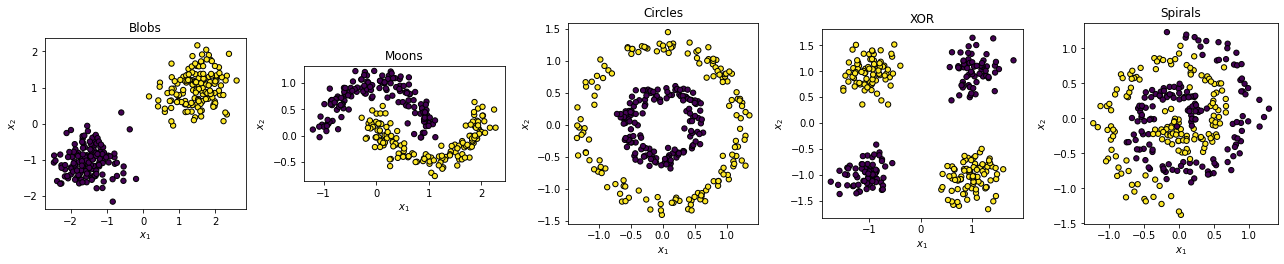

In [3]:
# Draw all five datasets side by side. (Learning some plotting along the way, because why not!!)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))

for axis, (name, builder) in zip(axes, DATASET_BUILDERS.items()):
    X, y = builder(n_samples=300, seed=RANDOM_STATE)

    axis.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="black",
        s=28,
    )

    axis.set_title(name)
    axis.set_xlabel(r"$x_1$")
    axis.set_ylabel(r"$x_2$")
    axis.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

Each dot is one event with two input features, $x_1$ and $x_2$. The color is its class label.

The neural network will not be told the words *moon*, *circle*, or *spiral*. It only receives the coordinates and the labels.

```{admonition} A useful physics analogy
:class: note

Imagine that $x_1$ and $x_2$ are two measured observables.

The classifier does not know the physical name of either class. Its task is only to learn which regions of the observable plane are usually occupied by each class.
```

In [4]:
def draw_interactive_dataset(dataset, noise, n_samples):
    builder = DATASET_BUILDERS[dataset]

    X, y = builder(
        n_samples=n_samples,
        noise=noise,
        seed=RANDOM_STATE,
    )

    plt.figure(figsize=(6, 5))
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="black",
        s=35,
    )

    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title(f"{dataset}: noise = {noise:.2f}")
    plt.grid(alpha=0.2)
    plt.show()


interact(
    draw_interactive_dataset,
    dataset=Dropdown(
        options=list(DATASET_BUILDERS),
        value="Moons",
        description="Dataset:",
        ),
        noise=FloatSlider(
            value=0.12,
            min=0.0,
            max=0.60,
            step=0.02,
            description="Noise:",
            continuous_update=False,
        ),
        n_samples=IntSlider(
            value=300,
            min=100,
            max=800,
            step=50,
            description="Samples:",
            continuous_update=False,
        ),
    )


interactive(children=(Dropdown(description='Dataset:', index=1, options=('Blobs', 'Moons', 'Circles', 'XOR', '…

<function __main__.draw_interactive_dataset(dataset, noise, n_samples)>

### What changed compared with SVM?

For a linear SVM, we directly asked for the widest straight separating boundary.

For a kernel SVM, we utilised the *kernel trick* that allowed the classifier to construct a nonlinear boundary.

For a neural network, we instead choose:

- the number of layers;
- the number of neurons;
- the activation function;
- the loss function;
- the optimization procedure.

The network then learns a collection of intermediate transformations whose combination produces the final boundary.

| Model | What do we choose? | What does the model learn? |
|---|---|---|
| Linear SVM | a linear kernel | the maximum-margin line |
| Kernel SVM | a nonlinear kernel | a nonlinear boundary in the kernel-induced space |
| Neural network | layers and activations | intermediate features and a decision boundary |

```{important}
The neural network does not automatically know the best architecture. The architecture is still a human choice à la **hyperparameter**.
```

### ❓ Exercise

**Q13:** Why can a neural network with only linear layers not solve the moon or circle datasets, no matter how many linear layers we stack?


---

## Reproducing the playground with PyTorch

We will now train a small PyTorch classifier on the same toy datasets.

Because these are tiny two-dimensional datasets, a CPU is more than sufficient. No GPU is needed.

In [5]:
import copy
import pandas as pd

import torch
import torch.nn as nn

torch.manual_seed(RANDOM_STATE)

# Begin with the standard check as always to see if we have a GPU/mps available, otherwise use CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


### Preparing one dataset

We will begin with the two-moons dataset.

The data are separated into:

- a **training set**, used to update the model;
- a **validation set**, used to choose when to stop or compare settings;
- a **test set**, used only for the final evaluation.

We normalize all features using the mean and standard deviation of the **training set only**. This avoids passing information from the validation or test samples into the training procedure.

In [ ]:
def prepare_dataset(
    dataset_name="Moons",
    n_train=300,
    n_validation=300,
    n_test=600,
    noise=0.12,
    seed=42,
):
    builder = DATASET_BUILDERS[dataset_name]

    X_train, y_train = builder(
        n_samples=n_train,
        noise=noise,
        seed=seed,
    )

    X_validation, y_validation = builder(
        n_samples=n_validation,
        noise=noise,
        seed=seed + 1,
    )

    X_test, y_test = builder(
        n_samples=n_test,
        noise=noise,
        seed=seed + 2,
    )

    mean = X_train.mean(axis=0)
    standard_deviation = X_train.std(axis=0)

    X_train = (X_train - mean) / standard_deviation
    X_validation = (X_validation - mean) / standard_deviation
    X_test = (X_test - mean) / standard_deviation
    
    arrays = {
        "X_train": X_train.astype(np.float32),
        "y_train": y_train.astype(np.int64),
        "X_validation": X_validation.astype(np.float32),
        "y_validation": y_validation.astype(np.int64),
        "X_test": X_test.astype(np.float32),
        "y_test": y_test.astype(np.int64),
    }
    # Convert the NumPy arrays to PyTorch tensors and move them to the specified device (CPU or GPU).
    tensors = {
        name: torch.tensor(array, device=device)
        for name, array in arrays.items()
    }

    return arrays, tensors


arrays, tensors = prepare_dataset(
    dataset_name="Moons",
    noise=0.14,
)

print("Training shape:", tensors["X_train"].shape)
print("Validation shape:", tensors["X_validation"].shape)
print("Test shape:", tensors["X_test"].shape)

Training shape: torch.Size([300, 2])
Validation shape: torch.Size([300, 2])
Test shape: torch.Size([600, 2])


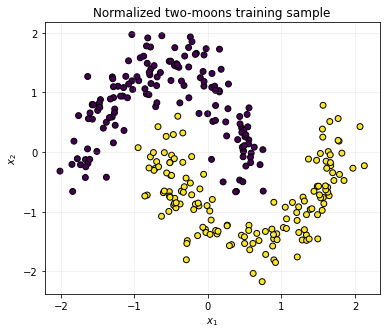

In [7]:
plt.figure(figsize=(6, 5))

plt.scatter(
    arrays["X_train"][:, 0],
    arrays["X_train"][:, 1],
    c=arrays["y_train"],
    edgecolor="black",
    s=35,
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Normalized two-moons training sample")
plt.grid(alpha=0.2)
plt.show()

### A flexible classifier

The following class lets us choose:

- how many hidden layers to use;
- how many neurons to put in each layer;
- whether to use ReLU or Tanh;
- how much dropout to apply.

The output layer has two numbers, one for each class. These raw outputs are called **logits** and are passed directly to `CrossEntropyLoss`.

In [8]:
# A fancy way to define a neural network in PyTorch is to use the `nn.Sequential` class, 
# which allows you to stack layers in a sequential manner. 
# In this example, we will define a simple feedforward neural network for binary classification using the `PlaygroundClassifier` class,
# closely mimicking the tensorflow playground example.

class PlaygroundClassifier(nn.Module):
    def __init__(
        self,
        hidden_sizes=(16, 16),
        activation="tanh",
        dropout=0.0,
    ):
        super().__init__()

        if activation == "relu":
            activation_layer = nn.ReLU
        elif activation == "tanh":
            activation_layer = nn.Tanh
        else:
            raise ValueError("activation must be 'relu' or 'tanh'") # Add some new activation functions here if you want to experiment with them.

        layers = []
        input_size = 2

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(activation_layer())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            input_size = hidden_size

        layers.append(nn.Linear(input_size, 2))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


model = PlaygroundClassifier(
    hidden_sizes=(16, 16),
    activation="tanh",
)

print(model)

number_of_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("\nTrainable parameters:", number_of_parameters)

PlaygroundClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

Trainable parameters: 354


In [9]:
def accuracy_from_logits(logits, labels):
    # Compute the accuracy of predictions given logits and true labels.
    predictions = logits.argmax(dim=1) # Get the predicted class by taking the index of the maximum logit for each sample.
    return (predictions == labels).float().mean().item()


def train_classifier(
    model,
    tensors,
    epochs=1000,
    learning_rate=1e-2,
    l1_strength=0.0, # Ignore this part for now, we will focus on the main training loop and the loss function.
    l2_strength=0.0, # Ignore this part for now, we will focus on the main training loop and the loss function.
    early_stopping=False,
    patience=80,
    minimum_improvement=1e-4,
    print_every=0,
):
    # Train a small full-batch classifier.
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = {
        "training_loss": [],
        "validation_loss": [],
        "training_accuracy": [],
        "validation_accuracy": [],
    }

    best_validation_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        training_logits = model(tensors["X_train"])
        data_loss = criterion(
            training_logits,
            tensors["y_train"],
        )
        # We will learn this in the next section, but for now, we will just add the L1 and L2 penalties to the loss function.
        l1_penalty = sum(
            parameter.abs().sum()
            for parameter in model.parameters()
        )

        l2_penalty = sum(
            parameter.pow(2).sum()
            for parameter in model.parameters()
        )

        loss = (
            data_loss
            + l1_strength * l1_penalty
            + l2_strength * l2_penalty
        )

        loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            validation_logits = model(
                tensors["X_validation"]
            )

            validation_loss = criterion(
                validation_logits,
                tensors["y_validation"],
            )

            training_accuracy = accuracy_from_logits(
                training_logits,
                tensors["y_train"],
            )

            validation_accuracy = accuracy_from_logits(
                validation_logits,
                tensors["y_validation"],
            )

        history["training_loss"].append(data_loss.item())
        history["validation_loss"].append(
            validation_loss.item()
        )
        history["training_accuracy"].append(
            training_accuracy
        )
        history["validation_accuracy"].append(
            validation_accuracy
        )

        if validation_loss.item() < (
            best_validation_loss - minimum_improvement
        ):
            best_validation_loss = validation_loss.item()
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if print_every and epoch % print_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"training loss = {data_loss.item():.4f} | "
                f"validation loss = {validation_loss.item():.4f}"
            )

        if (
            early_stopping
            and epochs_without_improvement >= patience
        ):
            break

    if early_stopping:
        model.load_state_dict(best_state)

    model.eval()

    with torch.no_grad():
        final_training_logits = model(tensors["X_train"])
        final_validation_logits = model(
            tensors["X_validation"]
        )
        final_test_logits = model(tensors["X_test"])

    result = {
        "model": model,
        "history": history,
        "epochs_trained": len(history["training_loss"]),
        "best_epoch": best_epoch,
        "training_accuracy": accuracy_from_logits(
            final_training_logits,
            tensors["y_train"],
        ),
        "validation_accuracy": accuracy_from_logits(
            final_validation_logits,
            tensors["y_validation"],
        ),
        "test_accuracy": accuracy_from_logits(
            final_test_logits,
            tensors["y_test"],
        ),
    }

    return result

In [10]:
def plot_decision_boundary(
    model,
    X,
    y,
    title="Decision boundary",
    axis=None,
):
    if axis is None:
        _, axis = plt.subplots(figsize=(6, 5))

    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )

    grid = np.column_stack([
        xx.ravel(),
        yy.ravel(),
    ]).astype(np.float32)

    model.eval()

    with torch.no_grad():
        probabilities = torch.softmax(
            model(torch.tensor(grid, device=device)),
            dim=1,
        )[:, 1]

    surface = probabilities.cpu().numpy().reshape(xx.shape)

    axis.contourf(
        xx,
        yy,
        surface,
        levels=np.linspace(0, 1, 21),
        alpha=0.6,
    )

    axis.contour(
        xx,
        yy,
        surface,
        levels=[0.5],
        linewidths=2,
    )

    axis.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor="black",
        s=32,
    )

    axis.set_xlabel(r"$x_1$")
    axis.set_ylabel(r"$x_2$")
    axis.set_title(title)


def plot_training_history(result, title="Training history"):
    history = result["history"]
    epochs = np.arange(1, len(history["training_loss"]) + 1)

    plt.figure(figsize=(7, 4))

    plt.plot(
        epochs,
        history["training_loss"],
        label="Training loss",
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        label="Validation loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

### A modest network on the moon dataset

We begin with two hidden layers, each containing 16 neurons.

This network is flexible enough to learn a curved boundary but not extravagantly large for the problem.

Training accuracy:   100.00%
Validation accuracy: 98.67%
Test accuracy:       99.67%


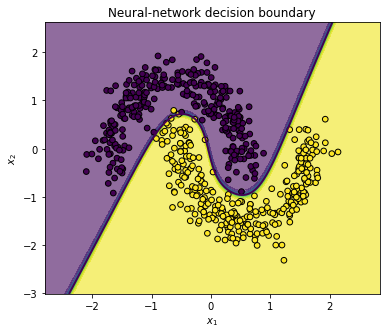

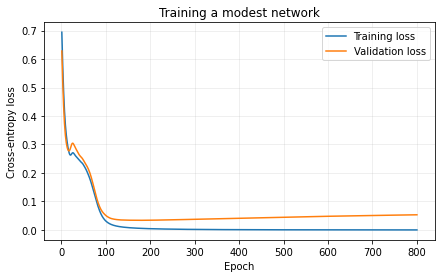

In [11]:
torch.manual_seed(RANDOM_STATE)

moon_model = PlaygroundClassifier(
    hidden_sizes=(16, 16),
    activation="tanh",
    dropout=0.0,
)

moon_result = train_classifier(
    moon_model,
    tensors,
    epochs=800,
    learning_rate=1e-2,
)

print(
    f"Training accuracy:   "
    f"{100*moon_result['training_accuracy']:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{100*moon_result['validation_accuracy']:.2f}%"
)

print(
    f"Test accuracy:       "
    f"{100*moon_result['test_accuracy']:.2f}%"
)

plot_decision_boundary(
    moon_result["model"],
    arrays["X_test"],
    arrays["y_test"],
    title="Neural-network decision boundary",
)

plt.show()

plot_training_history(
    moon_result,
    title="Training a modest network",
)

The decision boundary is nonlinear even though every individual linear layer only performs a weighted sum.

The nonlinear activation functions allow different neurons to describe different regions of the plane. The final layer combines those intermediate descriptions into one classification.

```{admonition} Compare with the SVM
:class: tip

The RBF-kernel SVM and the neural network may produce similarly curved boundaries, but they reach them differently.

- The SVM uses a chosen kernel to compare points.
- The neural network learns intermediate representations through its weights.
```

### ❓ Exercise

**Q14:** What do you expect if we replace

```python
hidden_sizes=(16, 16)
```

by each of the following?

```python
hidden_sizes=()
hidden_sizes=(2,)
hidden_sizes=(128, 128, 128)
```


### ❓ Challenge

Follow on with this chain of thought and produce the decision boundaries for the other datasets we created.

---

## Regularization: teaching the network to learn some restraint

A sufficiently flexible neural network can draw a complicated boundary around almost every training point.

That is not always an achievement.

If some training labels are noisy or incorrect, memorizing all of them can reduce the training loss while making predictions on new data worse.

**Regularization** is the general name for methods that discourage unnecessary complexity.

We will study four common ideas:

1. **L1 regularization**
2. **L2 regularization**
3. **Dropout**
4. **Early stopping** (Remeber your early study)

### L1 and L2 penalties

Let the ordinary data loss be $\mathcal{L}_{\rm data}$, and let all trainable parameters be represented by $\theta_i$.

With L1 regularization, we minimize

$$
\mathcal{L}
=
\mathcal{L}_{\rm data}
+
\lambda_1\sum_i|\theta_i|.
$$

With L2 regularization, we minimize

$$
\mathcal{L}
=
\mathcal{L}_{\rm data}
+
\lambda_2\sum_i\theta_i^2.
$$

The coefficients $\lambda_1$ and $\lambda_2$ decide how strongly we penalize large parameters.

- L1 often pushes some parameters very close to exactly zero.
- L2 usually shrinks parameters more smoothly.
- If the regularization is too weak, it changes almost nothing.
- If it is too strong, the model may become too simple and under-fit.

```{admonition} A physicist's way of reading it
:class: note

The optimizer now has two competing instructions:

1. fit the data;
2. avoid an unnecessarily complicated parameter configuration.

The coefficient $\lambda$ decides the relative importance of these two demands.
```

### Dropout

During training, dropout randomly removes a fraction of the hidden activations.

For example,

```python
nn.Dropout(p=0.30)
```

temporarily removes about 30% of those activations during each training step.

This prevents the model from relying too strongly on one particular route through the network.

```{important}
Dropout behaves differently during training and evaluation.

- `model.train()` turns dropout on.
- `model.eval()` turns dropout off.

Always call `model.eval()` before evaluating a trained model.
```

### Early stopping

Early stopping monitors the validation loss. When that loss stops improving, training is stopped and the best earlier model is restored.

This limits the amount of time available for memorizing statistical fluctuations.

### Constructing a deliberately troublesome dataset

To make regularization visible, we will create:

- only 80 training events;
- a large neural network;
- noisy moon-shaped data;
- ten deliberately flipped training labels.

The validation and test labels remain clean.

The unregularized model is therefore offered a temptation: it can either learn the general moon structure or spend its capacity memorizing the incorrect labels.

In [12]:
# Small noisy training sample
X_train_raw, y_train_clean = make_moons_numpy(
    n_samples=80,
    noise=0.18,
    seed=1,
)

# Flip ten training labels on purpose
rng = np.random.default_rng(2)
flipped_indices = rng.choice(
    len(y_train_clean),
    size=10,
    replace=False,
)

y_train_noisy = y_train_clean.copy()
y_train_noisy[flipped_indices] = (
    1 - y_train_noisy[flipped_indices]
)

# Larger clean validation and test samples
X_validation_raw, y_validation = make_moons_numpy(
    n_samples=300,
    noise=0.18,
    seed=3,
)

X_test_raw, y_test = make_moons_numpy(
    n_samples=1000,
    noise=0.18,
    seed=4,
)

# Normalize using only the training sample
mean = X_train_raw.mean(axis=0)
standard_deviation = X_train_raw.std(axis=0)

X_train = (
    (X_train_raw - mean) / standard_deviation
).astype(np.float32)

X_validation = (
    (X_validation_raw - mean) / standard_deviation
).astype(np.float32)

X_test = (
    (X_test_raw - mean) / standard_deviation
).astype(np.float32)

regularization_arrays = {
    "X_train": X_train,
    "y_train": y_train_noisy.astype(np.int64),
    "X_validation": X_validation,
    "y_validation": y_validation.astype(np.int64),
    "X_test": X_test,
    "y_test": y_test.astype(np.int64),
}

regularization_tensors = {
    name: torch.tensor(array, device=device)
    for name, array in regularization_arrays.items()
}

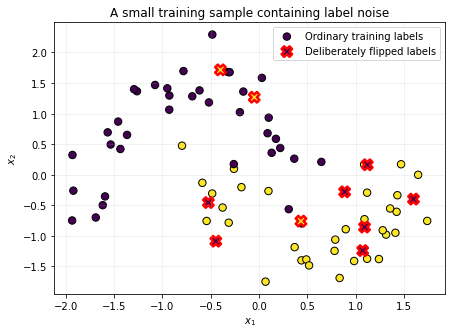

In [13]:
plt.figure(figsize=(7, 5))

# Correctly labelled training events
not_flipped = np.ones(len(X_train), dtype=bool)
not_flipped[flipped_indices] = False

plt.scatter(
    X_train[not_flipped, 0],
    X_train[not_flipped, 1],
    c=y_train_noisy[not_flipped],
    edgecolor="black",
    s=55,
    label="Ordinary training labels",
)

# Deliberately flipped labels
plt.scatter(
    X_train[flipped_indices, 0],
    X_train[flipped_indices, 1],
    c=y_train_noisy[flipped_indices],
    edgecolor="red",
    linewidth=2.5,
    marker="X",
    s=110,
    label="Deliberately flipped labels",
)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("A small training sample containing label noise")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The red-edged crosses are the deliberately incorrect labels.

A model that achieves 100% training accuracy must also memorize these mistakes.

That is why training accuracy alone is not sufficient for deciding whether a model is good.

In [14]:
def run_regularization_experiment(
    name,
    l1_strength=0.0,
    l2_strength=0.0,
    dropout=0.0,
    early_stopping=False,
):
    torch.manual_seed(RANDOM_STATE)

    model = PlaygroundClassifier(
        hidden_sizes=(64, 64, 64),
        activation="tanh",
        dropout=dropout,
    )

    result = train_classifier(
        model=model,
        tensors=regularization_tensors,
        epochs=1500,
        learning_rate=1e-2,
        l1_strength=l1_strength,
        l2_strength=l2_strength,
        early_stopping=early_stopping,
        patience=80,
    )

    result["name"] = name
    return result

# Run a series of experiments with different regularization techniques and store the results in a list. 
# Feel free to modify the parameters and add more experiments to explore the effects of regularization on model performance.

experiments = [
    run_regularization_experiment(
        name="No regularization",
    ),
    run_regularization_experiment(
        name="L1",
        l1_strength=1e-3,
    ),
    run_regularization_experiment(
        name="L2",
        l2_strength=1e-3,
    ),
    run_regularization_experiment(
        name="Dropout",
        dropout=0.30,
    ),
    run_regularization_experiment(
        name="Early stopping",
        early_stopping=True,
    ),
]

In [15]:
summary_rows = []

for result in experiments:
    summary_rows.append({
        "Method": result["name"],
        "Epochs used": result["epochs_trained"],
        "Training accuracy": result["training_accuracy"],
        "Validation accuracy": result["validation_accuracy"],
        "Test accuracy": result["test_accuracy"],
    })

summary = pd.DataFrame(summary_rows)

for column in [
    "Training accuracy",
    "Validation accuracy",
    "Test accuracy",
]:
    summary[column] = (
        100 * summary[column]
    ).round(2).astype(str) + "%"

summary

,Method,Epochs used,Training accuracy,Validation accuracy,Test accuracy
0,No regularization,1500,100.0%,78.67%,79.8%
1,L1,1500,97.5%,88.0%,89.3%
2,L2,1500,93.75%,80.67%,83.3%
3,Dropout,1500,91.25%,90.67%,90.7%
4,Early stopping,124,85.0%,99.0%,97.3%


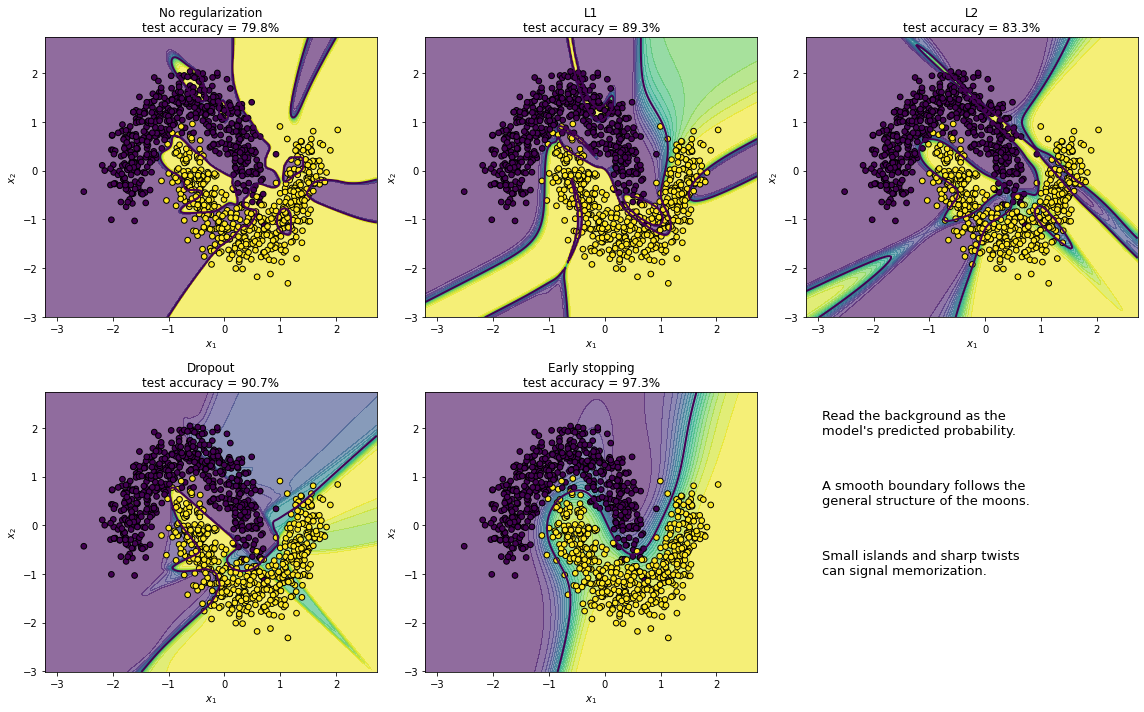

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for axis, result in zip(axes, experiments):
    plot_decision_boundary(
        result["model"],
        regularization_arrays["X_test"],
        regularization_arrays["y_test"],
        title=(
            f"{result['name']}\n"
            f"test accuracy = "
            f"{100*result['test_accuracy']:.1f}%"
        ),
        axis=axis,
    )

# The sixth panel contains the legend/explanation.
axes[-1].axis("off")
axes[-1].text(
    0.05,
    0.85,
    "Read the background as the\nmodel's predicted probability.",
    fontsize=13,
)

axes[-1].text(
    0.05,
    0.60,
    "A smooth boundary follows the\ngeneral structure of the moons.",
    fontsize=13,
)

axes[-1].text(
    0.05,
    0.35,
    "Small islands and sharp twists\ncan signal memorization.",
    fontsize=13,
)

plt.tight_layout()
plt.show()

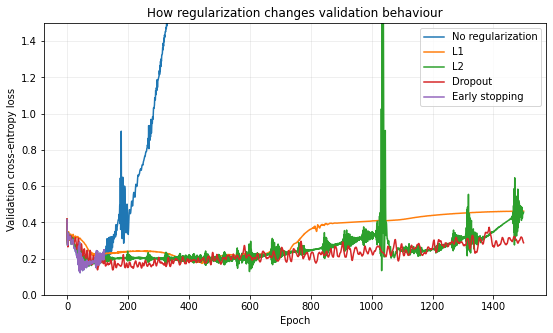

In [17]:
plt.figure(figsize=(9, 5))

for result in experiments:
    validation_loss = result["history"]["validation_loss"]

    plt.plot(
        validation_loss,
        label=result["name"],
    )

plt.xlabel("Epoch")
plt.ylabel("Validation cross-entropy loss")
plt.title("How regularization changes validation behaviour")
plt.ylim(0, 1.5)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Reading the result

The exact numbers may vary slightly, but the general pattern should be stable.

- The unregularized network can drive its training accuracy extremely high by learning the deliberately incorrect labels.
- Its decision boundary may develop small islands or sharp turns around individual training events.
- L1 and L2 penalize large parameters and can simplify the fit.
- Dropout makes memorization harder by changing the active subnetwork during training.
- Early stopping can stop the training before the validation behaviour deteriorates.

```{warning}
Regularization is not magic.

A bad feature choice, severe data leakage, incorrect labels, or a distribution shift cannot be repaired merely by increasing the dropout rate.
```

The regularization strength is itself a hyperparameter. It should be selected using validation data, not by repeatedly checking the final test sample.

### ❓ Exercise

**Q15:** Return to [TensorFlow Playground](https://playground.tensorflow.org/) and create an unnecessarily large network for the simple blob dataset.

Then:

1. increase the noise;
2. use several hidden layers and many neurons;
3. train until the boundary becomes unnecessarily complicated;
4. turn on L1 regularization;
5. repeat with L2 regularization;
6. watch both the decision boundary and the connection weights.

What qualitative difference do you expect between L1 and L2?

### ❓ Exercise

**Q16:** **A small PyTorch challenge:** Modify the experiment so that dropout takes the values

```python
0.0, 0.10, 0.30, 0.50, 0.80
```

Record the training, validation, and test accuracy for each value.

What do you expect when the dropout probability becomes very large?